# Laboratorio Sesión 6 — PCA, t-SNE y UMAP

**EIN092B: Técnicas de Visualización y Reducción de Dimensionalidad**

Grupo: `G5` — Integrantes: `Octavio Valencia - Lukas Garrido`

---
## 1. PCA — USArrests

PCA busca los ejes donde los datos "se estiran más": el primer eje (PC1) captura la
mayor varianza posible, el segundo (PC2) la mayor varianza que queda una vez sacado el
primero, y así sucesivamente. Sirve para comprimir datos y quedarnos con lo esencial.

### 1.1 Cargar y estandarizar

Antes de aplicar PCA hay que estandarizar (media 0, desviación 1), porque las
variables están en escalas muy distintas,si no, `Assault` (valores en cientos)
dominaría solo por su magnitud, no porque aporte más información.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.datasets import load_breast_cancer
from sklearn.datasets import fetch_olivetti_faces

In [2]:
data = pd.read_csv("USArrests.csv")
y_train = data.iloc[:,  0].values
x_train = data.iloc[:,  1:].values

scaler = StandardScaler()
x_train_std = scaler.fit_transform(x_train)

pca = PCA(n_components=2)
x_train_pca = pca.fit_transform(x_train_std)

print("Media por columna (debe ser ~0):", x_train_std.mean(axis=0))
print("Desviación estándar por columna (debe ser ~1):", x_train_std.std(axis=0))
print("Dimensiones después de PCA:", x_train_pca.shape)

print("--------------------------------------------------------------")
# Varianza explicada por cada componente (proporción del total)
print("Varianza explicada por componente:", pca.explained_variance_ratio_)
# Varianza total capturada por las 2 primeras componentes
print("Varianza total explicada:", pca.explained_variance_ratio_.sum())

Media por columna (debe ser ~0): [-7.10542736e-17  1.38777878e-16 -4.39648318e-16  8.59312621e-16]
Desviación estándar por columna (debe ser ~1): [1. 1. 1. 1.]
Dimensiones después de PCA: (50, 2)
--------------------------------------------------------------
Varianza explicada por componente: [0.62006039 0.24744129]
Varianza total explicada: 0.8675016829223337


La estandarización debería dejar medias ~0 y desviaciones ~1. La varianza explicada nos dice cuánta información de las 4 variables originales quedó retenida en solo 2 componentes.

### 1.2 Biplot: dispersión + eigenvectores

Graficamos los estados en el plano PC1–PC2 y encima dibujamos los eigenvectores, que
muestran cómo influye cada variable original en cada componente.

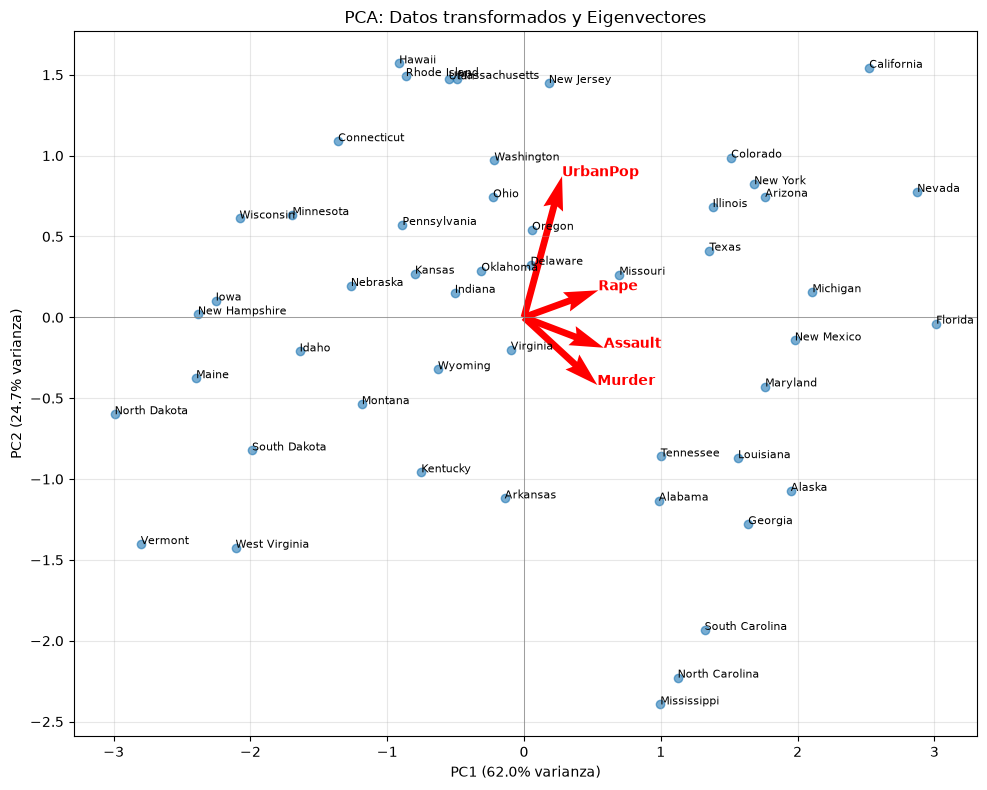

In [3]:
# Nombres de los estados (asumiendo que están en la primera columna del CSV,
# o en el índice del dataframe original)
state_names = data.iloc[:, 0].values  # ajusta según cómo tengas cargado tu CSV

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(x_train_pca[:, 0], x_train_pca[:, 1], alpha=0.6)

# Nombre de cada estado sobre su punto correspondiente
for i, name in enumerate(state_names):
    ax.annotate(name, (x_train_pca[i, 0], x_train_pca[i, 1]), fontsize=8)

# --- Vectores propios (eigenvectors) ---
eigenvectors = pca.components_

for i in range(4):
    ax.quiver(0, 0, eigenvectors[0, i], eigenvectors[1, i],
               angles='xy', scale_units='xy', scale=1, color='r')

for i, word in enumerate(['Murder', 'Assault', 'UrbanPop', 'Rape']):
    ax.annotate(word, (eigenvectors[0, i], eigenvectors[1, i]),
                color='red', fontsize=10, fontweight='bold')

ax.set_title('PCA: Datos transformados y Eigenvectores')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Cada punto es un estado, los de la derecha tienen más
criminalidad violenta combinada, los de la izquierda menos. Las flechas rojas son las
variables, si dos flechas apuntan casi para el mismo lado, esas variables están
correlacionadas, si quedan casi perpendiculares, no tienen mucha relación entre sí.

### 1.3 Para responder

1. ¿Por qué crees que `Murder`, `Assault` y `Rape` están ubicadas cerca unas de otras en el espacio de los componentes principales?

Porque están correlacionadas entre sí, ya que en un biplot de PCA, el ángulo entre dos flechas refleja qué tan correlacionadas están esas variables. Los ángulos pequeños (flechas casi paralelas) indican correlación positiva fuerte. Como estas tres apuntan casi en la misma dirección, significa que los estados con tasas altas de un tipo de crimen violento tienden a tener tasas altas de los otros dos también.

2. ¿Qué indica esto sobre la relación entre estas variables?

Que probablemente comparten causas comunes como: condiciones socioeconómicas, políticas de seguridad pública, desigualdad, etc. Al estar tan correlacionadas, PCA las "junta" en una sola dirección dominante: por eso PC1 (que explica el 62% de la varianza) puede interpretarse casi como un índice general de criminalidad violenta, más que como tres fenómenos independientes.

3. ¿Qué podría significar el hecho de que `UrbanPop` esté más lejos de las otras tres variables?

Que no está correlacionada (o muy poco) con la criminalidad violenta en este dataset. Su flecha queda casi perpendicular a las otras tres, indica ausencia de relación lineal. Esto es un poco contraintuitivo: uno esperaría que "más urbano = más crimen", pero el dato muestra que hay estados muy urbanos con crimen bajo (Massachusetts, Rhode Island) y estados poco urbanos con crimen alto (Mississippi, Carolina del Sur). Por eso UrbanPop termina dominando más bien PC2 (24.7% de la varianza), un eje casi independiente del de criminalidad.

---
## 2. t-SNE — Olivetti faces

t-SNE es no lineal y está pensado para visualizar: en vez de preservar la varianza
global como PCA, trata de mantener juntos a los puntos que ya eran "vecinos" en el
espacio original.

*Olivetti faces*: 400 fotos (10 por persona) de 40 personas distintas, 64×64 píxeles
cada una.

### 2.1 Cargar y centrar

Centramos las imágenes (por píxel y luego por muestra), un preprocesamiento típico
antes de aplicar PCA a este tipo de datos.

In [4]:
import logging
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import RandomState

from sklearn.decomposition import PCA
from sklearn.datasets import fetch_olivetti_faces

rng = RandomState(0)

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")

# Cargar dataset
faces, labels = fetch_olivetti_faces(return_X_y=True, shuffle=True, random_state=rng)
n_samples, n_features = faces.shape

print("El dataset consiste de %d caras" % n_samples)
print("Dimensiones de faces:", faces.shape)   # (400, 10304)
print("Dimensiones de labels:", labels.shape) # (400,) -> 40 clases, 10 imágenes c/u

# Centrado global (por feature, sobre todas las muestras)
faces_centered = faces - faces.mean(axis=0)

# Centrado local (por muestra, sobre todos los features)
faces_centered -= faces_centered.mean(axis=1).reshape(n_samples, -1)

El dataset consiste de 400 caras
Dimensiones de faces: (400, 4096)
Dimensiones de labels: (400,)


### 2.2 PCA a 30 componentes primero

Antes de t-SNE conviene bajar la dimensión con PCA: t-SNE es lento en alta dimensión,
y de paso PCA saca algo de ruido.

In [5]:
pca_30 = PCA(n_components=30, random_state=0)
x_pca_30 = pca_30.fit_transform(faces_centered)

print("Dimensiones después de PCA:", x_pca_30.shape)  # (400, 30)
print("Varianza total explicada por 30 componentes:", pca_30.explained_variance_ratio_.sum())

Dimensiones después de PCA: (400, 30)
Varianza total explicada por 30 componentes: 0.7715989


Veamos cuánta varianza va quedando retenida a medida que sumamos componentes:

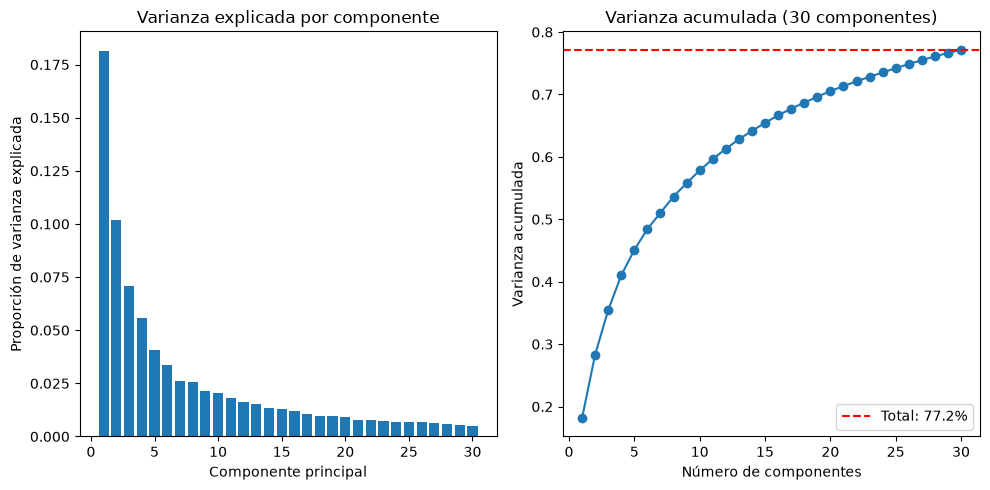

In [6]:
plt.figure(figsize=(10, 5))

# Varianza individual por componente
plt.subplot(1, 2, 1)
plt.bar(range(1, 31), pca_30.explained_variance_ratio_)
plt.xlabel('Componente principal')
plt.ylabel('Proporción de varianza explicada')
plt.title('Varianza explicada por componente')

# Varianza acumulada
plt.subplot(1, 2, 2)
plt.plot(range(1, 31), np.cumsum(pca_30.explained_variance_ratio_), marker='o')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.title('Varianza acumulada (30 componentes)')
plt.axhline(y=pca_30.explained_variance_ratio_.sum(), color='r', linestyle='--',
            label=f'Total: {pca_30.explained_variance_ratio_.sum()*100:.1f}%')
plt.legend()

plt.tight_layout()
plt.show()

Las barras muestran cuánto aporta cada componente por sí sola
(cae rápido, como es normal en PCA). La línea es el acumulado — te dice qué porcentaje
del total ya llevas retenido con 30 componentes.

### 2.3 t-SNE con perplexity=40

Aplicamos t-SNE sobre esas 30 componentes (no sobre los píxeles crudos). Después
tomamos una clase al azar y comparamos sus caras reales con dónde quedaron en el mapa.

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 400 samples in 0.000s...
[t-SNE] Computed neighbors for 400 samples in 0.052s...
[t-SNE] Computed conditional probabilities for sample 400 / 400
[t-SNE] Mean sigma: 3.345358
[t-SNE] KL divergence after 250 iterations with early exaggeration: 55.672615
[t-SNE] KL divergence after 1000 iterations: 0.594907
Dimensiones después de t-SNE: (400, 2)


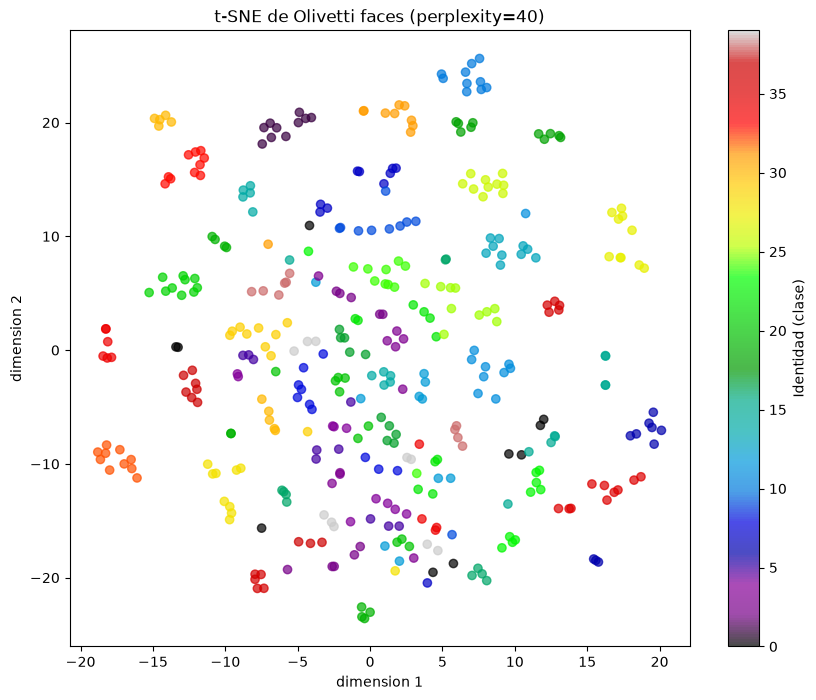

Coordenadas t-SNE de la clase 5:
[[ -3.7290037   -9.570835  ]
 [  0.03031141 -14.835822  ]
 [ -8.782616    -0.46202594]
 [ -2.1649833   -8.704355  ]
 [  1.2815083  -15.467673  ]
 [ -8.058562    -0.8226933 ]
 [  2.011585   -15.468657  ]
 [ -8.384481    -0.42250407]
 [ -1.3295645   -4.5616193 ]
 [ -3.6840198   -8.783023  ]]


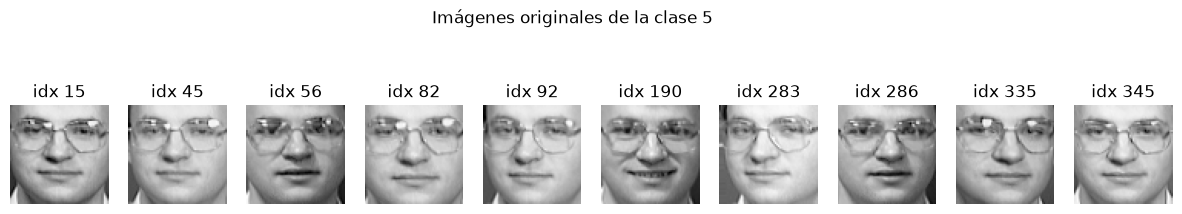

In [7]:
from sklearn.manifold import TSNE

# t-SNE sobre la representación de 30 componentes
tsne = TSNE(n_components=2, verbose=1, perplexity=40, random_state=0)
x_tsne = tsne.fit_transform(x_pca_30)
print("Dimensiones después de t-SNE:", x_tsne.shape)

# Scatter coloreado por clase
plt.figure(figsize=(10, 8))
scatter = plt.scatter(x_tsne[:, 0], x_tsne[:, 1], c=labels, cmap='nipy_spectral', alpha=0.7)
plt.colorbar(scatter, label='Identidad (clase)')
plt.title('t-SNE de Olivetti faces (perplexity=40)')
plt.xlabel('dimension 1')
plt.ylabel('dimension 2')
plt.show()

# Inspección de un subgrupo: elegimos una clase y vemos si sus puntos están cerca en t-SNE
clase_ejemplo = 5
idx_clase = np.where(labels == clase_ejemplo)[0]
print(f"Coordenadas t-SNE de la clase {clase_ejemplo}:")
print(x_tsne[idx_clase])

# Mostrar las imágenes originales de esa clase para comparar
fig, axes = plt.subplots(1, len(idx_clase), figsize=(15, 3))
for ax, idx in zip(axes, idx_clase):
    ax.imshow(faces[idx].reshape(64, 64), cmap='gray')
    ax.set_title(f'idx {idx}')
    ax.axis('off')
plt.suptitle(f'Imágenes originales de la clase {clase_ejemplo}')
plt.show()

En el scatter, cada color es una persona distinta, si t-SNE
hizo bien su trabajo, las 10 fotos de cada persona deberían quedar agrupaditas. Las
fotos de abajo son la comprobación: si esas 10 caras se parecen entre sí, tiene sentido
que t-SNE las haya puesto juntas.

### 2.4 Jugando con `perplexity`

In [8]:
from ipywidgets import interactive
import matplotlib.pyplot as plt

def tsne_pipeline(perplexity):
    tsne = TSNE(n_components=2, verbose=0, perplexity=perplexity, random_state=0)
    z = tsne.fit_transform(x_pca_30)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(z[:, 0], z[:, 1], c=labels, cmap='nipy_spectral', alpha=0.7)
    plt.colorbar(scatter, label='Identidad (clase)')
    plt.title(f't-SNE con perplexity={perplexity}')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.show()

interactive_plot = interactive(tsne_pipeline, perplexity=(5, 100, 5))
interactive_plot

interactive(children=(IntSlider(value=50, description='perplexity', min=5, step=5), Output()), _dom_classes=('…

Mueve el slider y observa: con `perplexity` bajo, t-SNE se enfoca mucho en lo
local y tiende a fragmentar en muchos grupitos, con valores altos mira más "en
grande" pero puede empezar a mezclar clases, sobre todo considerando que acá solo hay
400 caras en total.

### 2.5 PCA (2 componentes) vs t-SNE

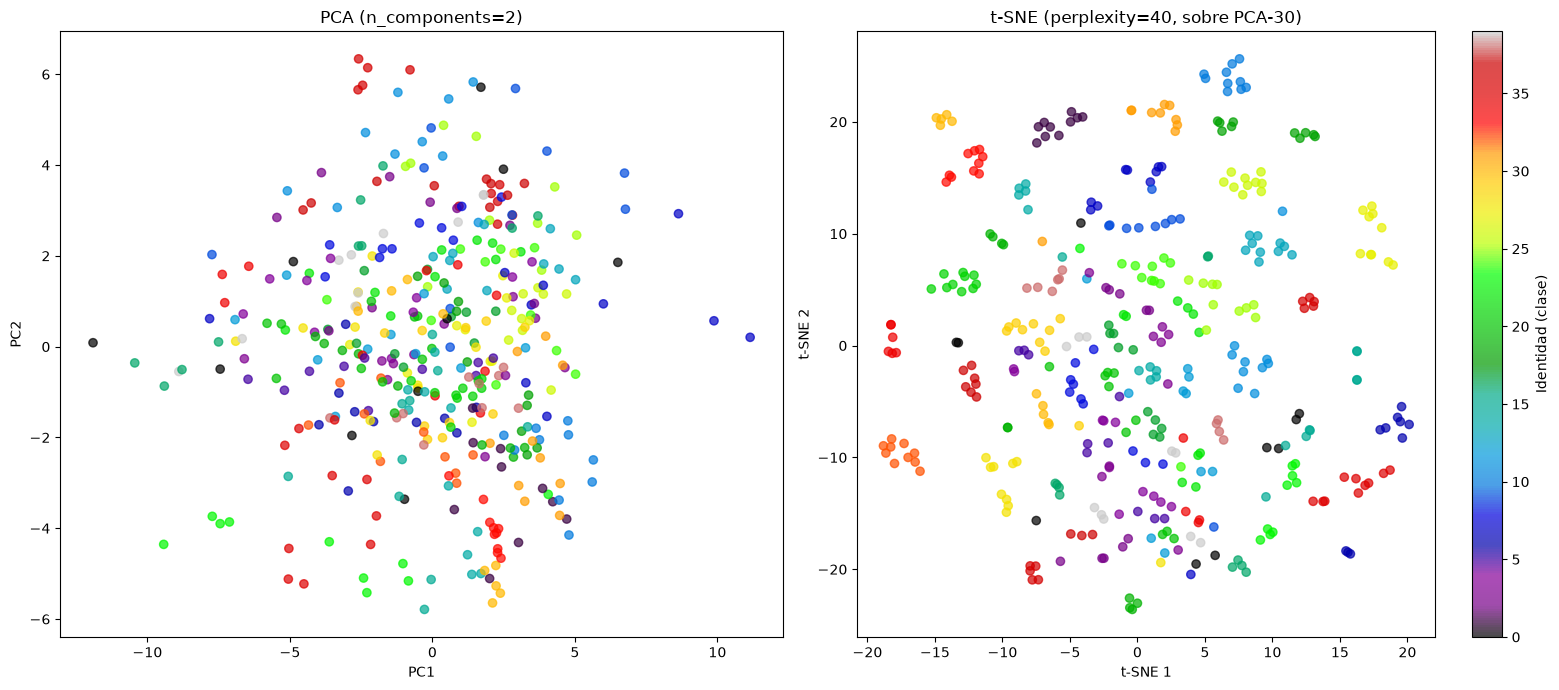

In [9]:
# PCA directo a 2 componentes (sin pasar por 30 dimensiones)
pca_2 = PCA(n_components=2, random_state=0)
x_pca_2 = pca_2.fit_transform(faces_centered)

# Comparación lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sc1 = axes[0].scatter(x_pca_2[:, 0], x_pca_2[:, 1], c=labels, cmap='nipy_spectral', alpha=0.7)
axes[0].set_title('PCA (n_components=2)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

sc2 = axes[1].scatter(x_tsne[:, 0], x_tsne[:, 1], c=labels, cmap='nipy_spectral', alpha=0.7)
axes[1].set_title('t-SNE (perplexity=40, sobre PCA-30)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

plt.colorbar(sc2, ax=axes[1], label='Identidad (clase)')
plt.tight_layout()
plt.show()

Compara ambos paneles. PCA (izquierda) debería verse más
mezclado, ya que 2 componentes lineales no alcanzan para separar bien algo tan
complejo como caras. t-SNE (derecha) debería mostrar clústeres bastante más definidos,
justamente porque fue diseñado para eso.

---
## 3. UMAP — Fashion-MNIST

UMAP también es no lineal, pero en vez de basarse en probabilidades como t-SNE,
construye un grafo de vecindades y trata de preservar su forma. Suele ser más rápido y
conservar mejor la estructura "global" (cómo se relacionan los grupos entre sí, no solo
puntos individuales).

*Fashion-MNIST*: 60.000 imágenes de ropa (28×28 px), 10 categorías.

### 3.1 PCA + UMAP

Mismo patrón que con t-SNE: primero PCA a 30 componentes, luego UMAP a 2D.

Dimensiones de x_train: (70000, 784)
Dimensiones de y_train: (70000,)
Varianza total explicada por 30 componentes: 0.82062006


c:\Users\lukas\Desktop\Personal\G5 Sesion4\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Dimensiones del embedding: (70000, 2)


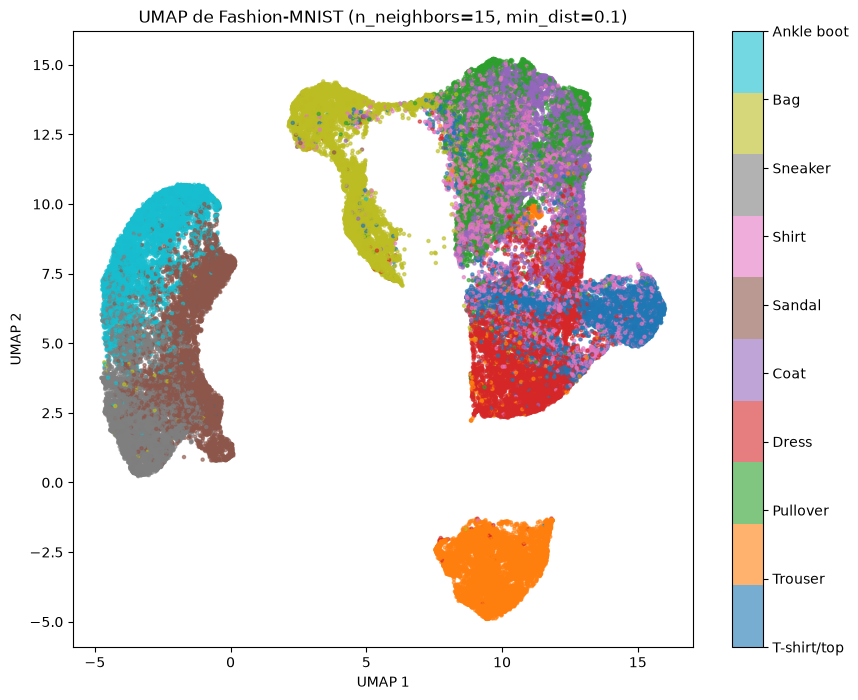

In [10]:
import umap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA

# Cargar dataset (la primera vez descarga ~60.000 imágenes, puede tardar)
fashion_mnist = fetch_openml('Fashion-MNIST', version=1, as_frame=False)
x_train = fashion_mnist.data.astype(np.float32) / 255.0
y_train = fashion_mnist.target.astype(int)

print("Dimensiones de x_train:", x_train.shape)
print("Dimensiones de y_train:", y_train.shape)

# PCA a 30 componentes
pca_30 = PCA(n_components=30, random_state=0)
x_pca_30 = pca_30.fit_transform(x_train)
print("Varianza total explicada por 30 componentes:", pca_30.explained_variance_ratio_.sum())

# UMAP sobre la representación de 30 componentes
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=0)
embedding = reducer.fit_transform(x_pca_30)
print("Dimensiones del embedding:", embedding.shape)

# Nombres de las 10 clases de Fashion-MNIST (según documentación oficial)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Gráfico coloreado por clase
plt.figure(figsize=(10, 8))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=y_train, cmap='tab10', s=5, alpha=0.6)
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.ax.set_yticklabels(class_names)
plt.title('UMAP de Fashion-MNIST (n_neighbors=15, min_dist=0.1)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

Cada punto es una prenda, coloreada por categoría.

### 3.2 Probando `n_neighbors` y `min_dist`

c:\Users\lukas\Desktop\Personal\G5 Sesion4\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\lukas\Desktop\Personal\G5 Sesion4\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\lukas\Desktop\Personal\G5 Sesion4\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\lukas\Desktop\Personal\G5 Sesion4\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\lukas\Desktop\Personal\G5 Sesion4\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\lukas\Desktop\Personal\G5 Sesio

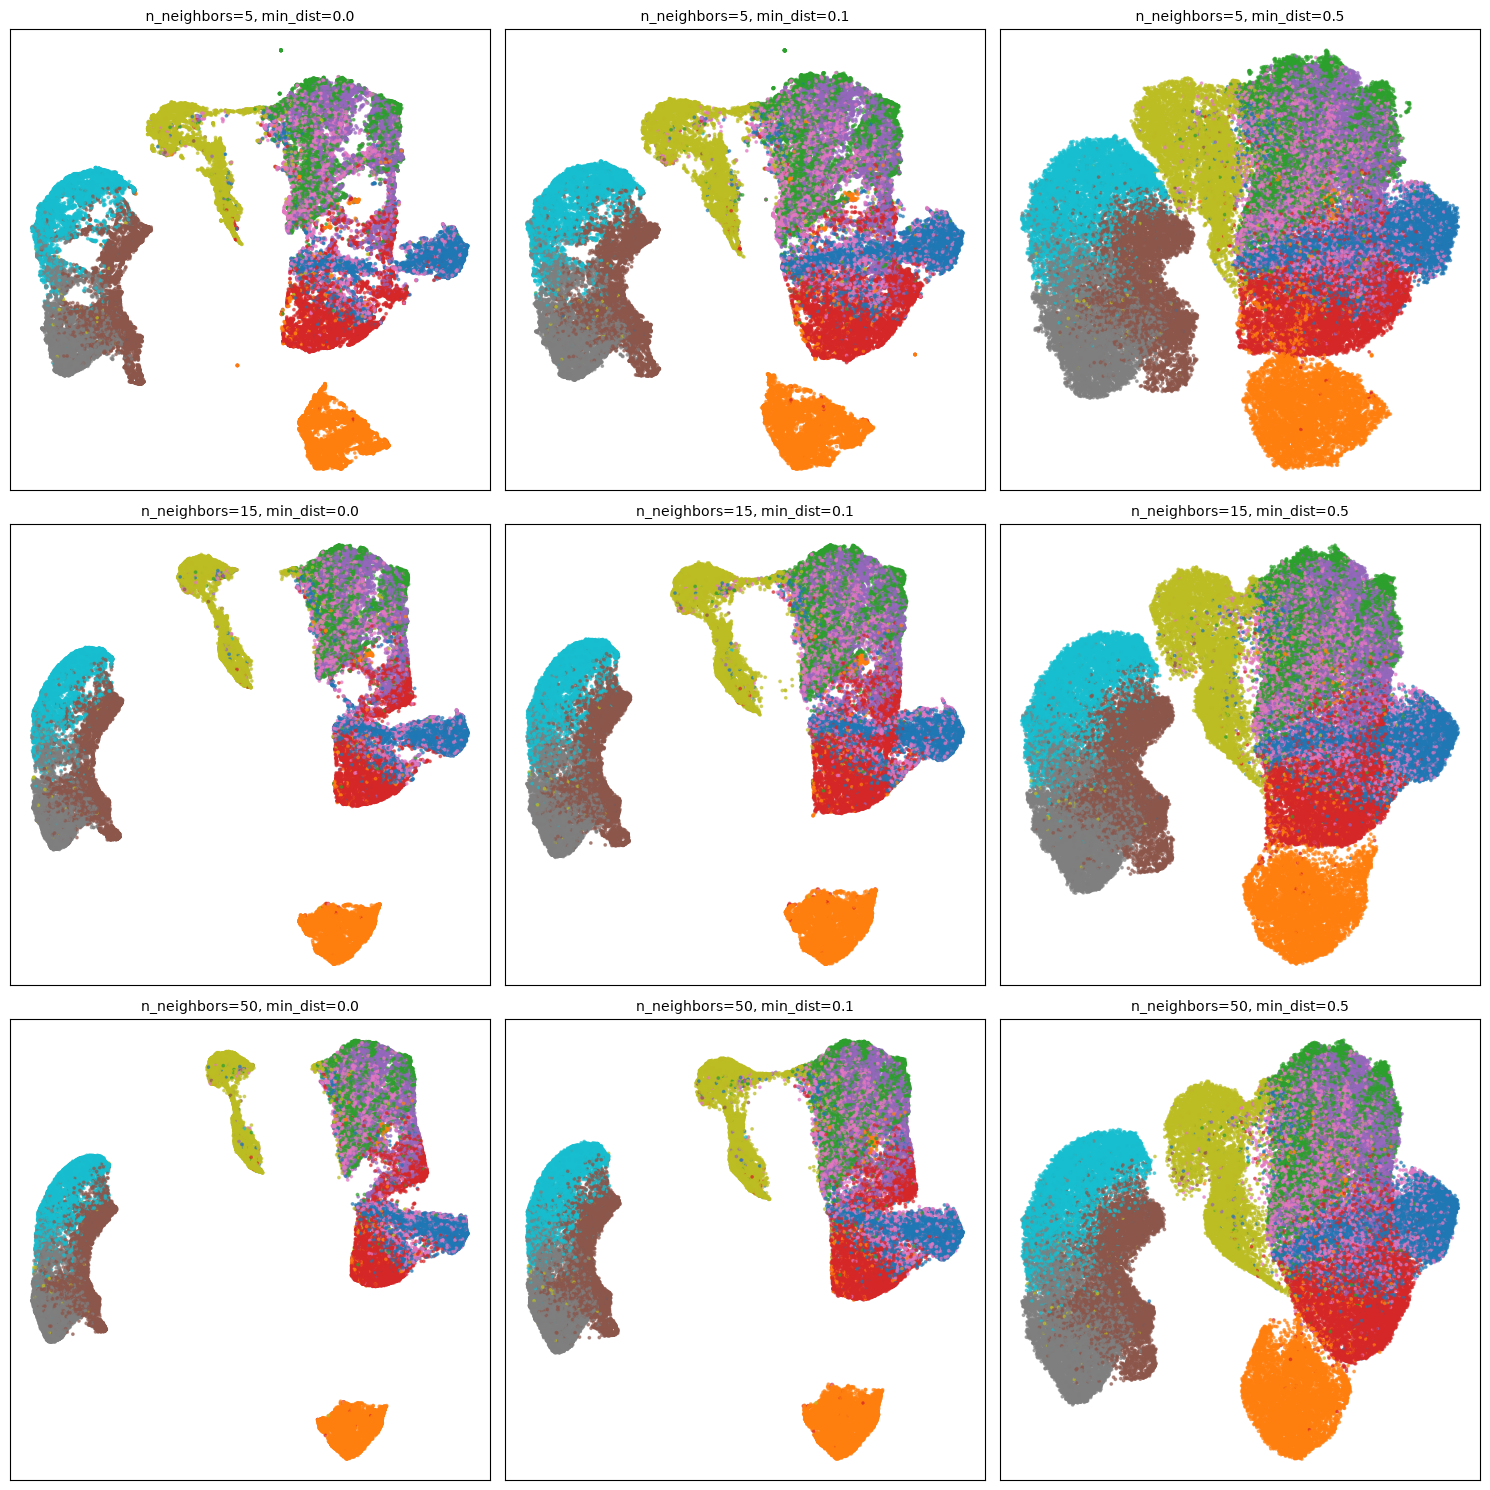

In [11]:
n_neighbors_values = [5, 15, 50]   # pequeño, intermedio, grande
min_dist_values = [0.0, 0.1, 0.5]  # compacto, intermedio, disperso

fig, axes = plt.subplots(len(n_neighbors_values), len(min_dist_values), figsize=(15, 15))

for i, nn in enumerate(n_neighbors_values):
    for j, md in enumerate(min_dist_values):
        reducer_bench = umap.UMAP(n_neighbors=nn, min_dist=md, n_components=2, random_state=0)
        emb_bench = reducer_bench.fit_transform(x_pca_30)

        ax = axes[i, j]
        ax.scatter(emb_bench[:, 0], emb_bench[:, 1], c=y_train, cmap='tab10', s=3, alpha=0.6)
        ax.set_title(f'n_neighbors={nn}, min_dist={md}', fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

Cada celda de la grilla es una corrida distinta. `n_neighbors`
bajo = más foco local (grupos chicos y fragmentados); alto = vista más global y
suave. `min_dist` bajo = clústeres compactos y apretados; alto = puntos más
esparcidos dentro de cada grupo.

### 3.3 Probando distintas `metric`

c:\Users\lukas\Desktop\Personal\G5 Sesion4\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\lukas\Desktop\Personal\G5 Sesion4\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\lukas\Desktop\Personal\G5 Sesion4\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\lukas\Desktop\Personal\G5 Sesion4\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


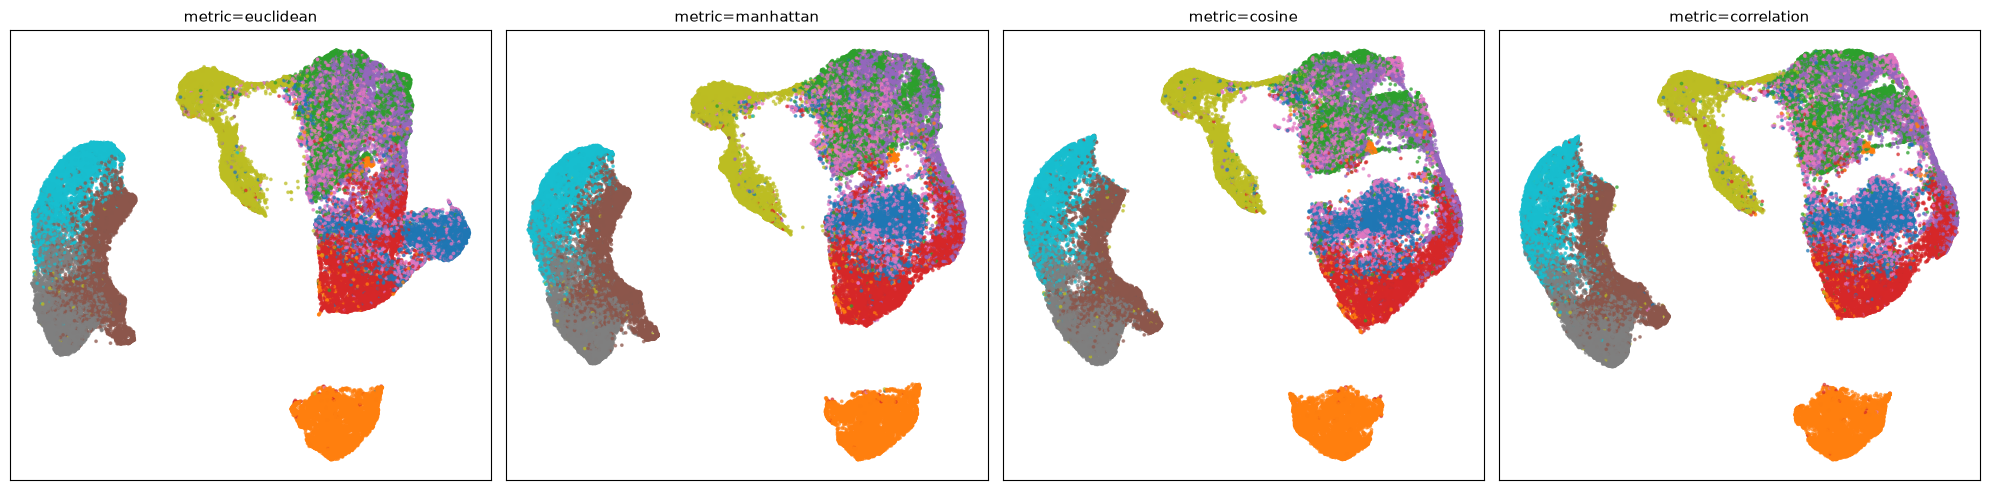

In [12]:
metrics = ['euclidean', 'manhattan', 'cosine', 'correlation']

fig, axes = plt.subplots(1, len(metrics), figsize=(20, 5))

for ax, metric in zip(axes, metrics):
    reducer_metric = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2,
                                 metric=metric, random_state=0)
    emb_metric = reducer_metric.fit_transform(x_pca_30)

    ax.scatter(emb_metric[:, 0], emb_metric[:, 1], c=y_train, cmap='tab10', s=3, alpha=0.6)
    ax.set_title(f'metric={metric}', fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

Cada panel usa una forma distinta de medir "distancia" entre
imágenes. `euclidean`/`manhattan` miran la magnitud de los píxeles; `cosine`/`correlation`
miran más el "patrón" o dirección, ignorando la escala, por eso suelen preferirse
para datos como texto, más que para imágenes.

### 3.4 Widget interactivo

In [13]:
from ipywidgets import interactive

def umap_pipeline(n_neighbors, min_dist):
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist,
                         n_components=2, random_state=0)
    z = reducer.fit_transform(x_pca_30)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(z[:, 0], z[:, 1], c=y_train, cmap='tab10', s=5, alpha=0.6)
    plt.colorbar(scatter, ticks=range(10))
    plt.title(f'UMAP: n_neighbors={n_neighbors}, min_dist={min_dist}')
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.show()

interactive_plot = interactive(umap_pipeline, n_neighbors=(2, 200, 5), min_dist=(0.0, 1.0, 0.05))
interactive_plot

interactive(children=(IntSlider(value=97, description='n_neighbors', max=200, min=2, step=5), FloatSlider(valu…

In [14]:
# Opcional: usar una muestra más pequeña para que el widget responda más rápido
idx_sample = np.random.RandomState(0).choice(len(x_pca_30), 5000, replace=False)
x_pca_30_sample = x_pca_30[idx_sample]
y_train_sample = y_train[idx_sample]

Con 60.000 imágenes, recalcular UMAP en cada movimiento del slider es lento,
por eso usamos una muestra de 5.000 para que el widget responda mejor.

### 3.5 t-SNE vs UMAP, cara a cara

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 70000 samples in 0.001s...
[t-SNE] Computed neighbors for 70000 samples in 4.674s...
[t-SNE] Computed conditional probabilities for sample 1000 / 70000
[t-SNE] Computed conditional probabilities for sample 2000 / 70000
[t-SNE] Computed conditional probabilities for sample 3000 / 70000
[t-SNE] Computed conditional probabilities for sample 4000 / 70000
[t-SNE] Computed conditional probabilities for sample 5000 / 70000
[t-SNE] Computed conditional probabilities for sample 6000 / 70000
[t-SNE] Computed conditional probabilities for sample 7000 / 70000
[t-SNE] Computed conditional probabilities for sample 8000 / 70000
[t-SNE] Computed conditional probabilities for sample 9000 / 70000
[t-SNE] Computed conditional probabilities for sample 10000 / 70000
[t-SNE] Computed conditional probabilities for sample 11000 / 70000
[t-SNE] Computed conditional probabilities for sample 12000 / 70000
[t-SNE] Computed conditional probabilities for sam

c:\Users\lukas\Desktop\Personal\G5 Sesion4\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Tiempo t-SNE: 556.8s
Tiempo UMAP: 481.8s


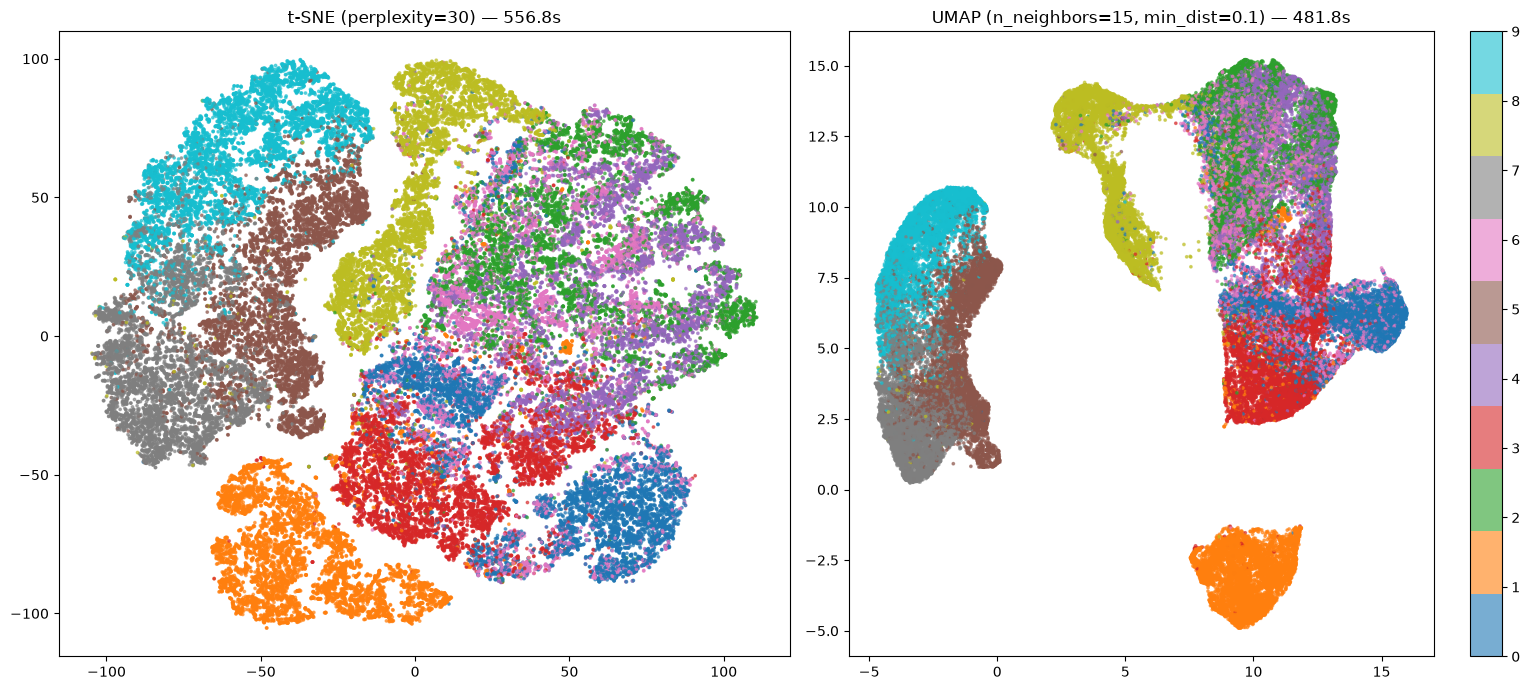

In [15]:
from sklearn.manifold import TSNE
import time

# t-SNE con hiperparámetro razonable fijo
t0 = time.time()
tsne_fm = TSNE(n_components=2, perplexity=30, random_state=0, verbose=1)
x_tsne_fm = tsne_fm.fit_transform(x_pca_30)
t_tsne = time.time() - t0

# UMAP con hiperparámetro razonable fijo
t0 = time.time()
reducer_fm = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=0)
x_umap_fm = reducer_fm.fit_transform(x_pca_30)
t_umap = time.time() - t0

print(f"Tiempo t-SNE: {t_tsne:.1f}s")
print(f"Tiempo UMAP: {t_umap:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sc1 = axes[0].scatter(x_tsne_fm[:, 0], x_tsne_fm[:, 1], c=y_train, cmap='tab10', s=3, alpha=0.6)
axes[0].set_title(f't-SNE (perplexity=30) — {t_tsne:.1f}s')

sc2 = axes[1].scatter(x_umap_fm[:, 0], x_umap_fm[:, 1], c=y_train, cmap='tab10', s=3, alpha=0.6)
axes[1].set_title(f'UMAP (n_neighbors=15, min_dist=0.1) — {t_umap:.1f}s')

plt.colorbar(sc2, ax=axes[1], ticks=range(10))
plt.tight_layout()
plt.show()

Es el mismo dato, dos técnicas, con el tiempo de cómputo de cada una
en el título. Compara tanto qué tan bien separan las clases como cuánto se demoró cada
una, normalmente UMAP gana en velocidad y no se queda atrás en separación.

### 3.6 UMAP semi-supervisado

c:\Users\lukas\Desktop\Personal\G5 Sesion4\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


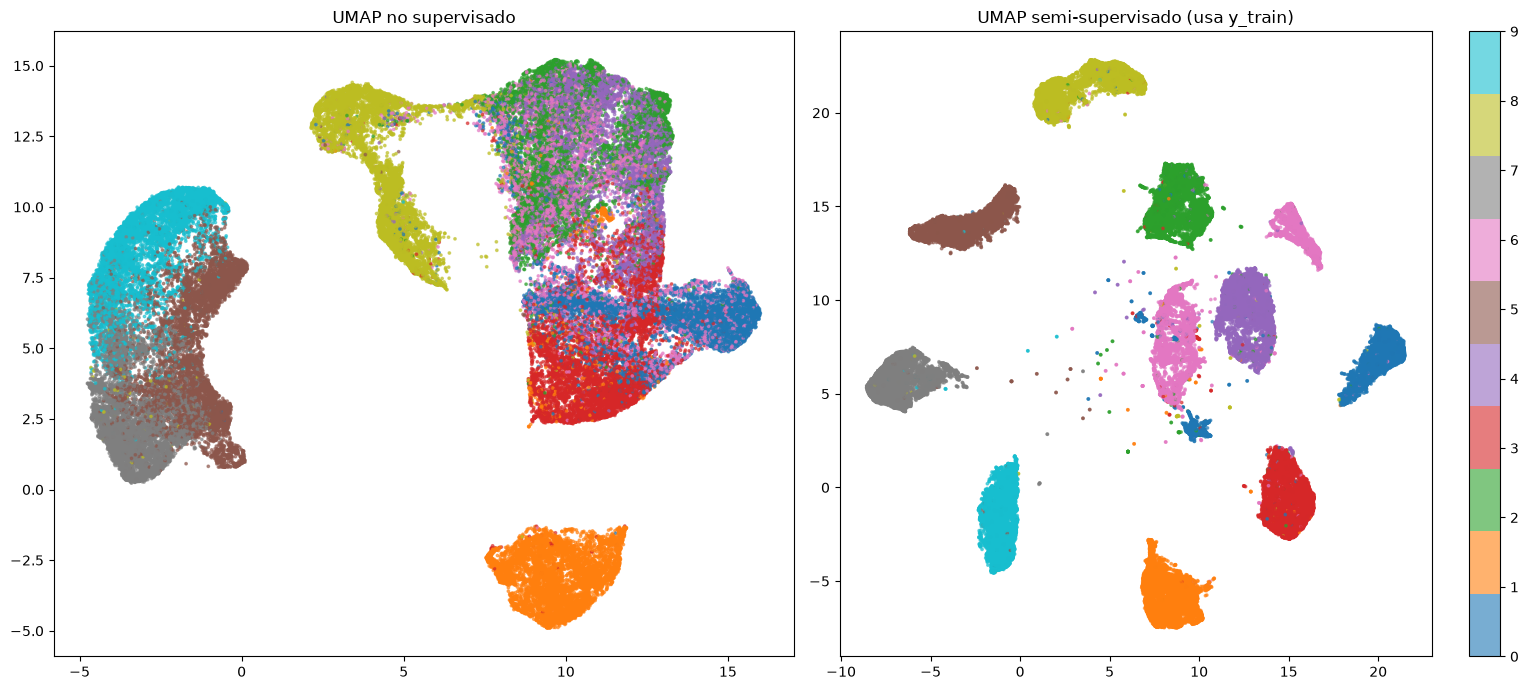

In [16]:
# Versión semi-supervisada: se pasa y_train durante el fit
reducer_semi = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=0)
embedding_semi = reducer_semi.fit_transform(x_pca_30, y=y_train)

# Comparación no-supervisado (punto 1) vs semi-supervisado
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sc1 = axes[0].scatter(embedding[:, 0], embedding[:, 1], c=y_train, cmap='tab10', s=3, alpha=0.6)
axes[0].set_title('UMAP no supervisado')

sc2 = axes[1].scatter(embedding_semi[:, 0], embedding_semi[:, 1], c=y_train, cmap='tab10', s=3, alpha=0.6)
axes[1].set_title('UMAP semi-supervisado (usa y_train)')

plt.colorbar(sc2, ax=axes[1], ticks=range(10))
plt.tight_layout()
plt.show()

A la derecha, UMAP recibió las etiquetas reales durante el
ajuste, así que los grupos deberían verse mucho más ordenados y separados que en la
versión sin supervisión (izquierda). Ojo: esto no es una forma válida de "evaluar" qué
tan bien separa UMAP sin ayuda le estamos dando la respuesta de antemano.